Task 3: Trying ways to learn concept Z: 'Populism'   
   
Import PyToch and OpenAI CLIP to analyze text and images (We can use these libraries to analyze the images we generated in Task 2)

In [8]:
import torch
import clip
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity
import csv
import re

Load CLIP model and images from 'Populism Images'

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

image_folder = "populism images"
images = []
filenames = []

for root, dirs, files in os.walk(image_folder):
    for fname in files:
        if fname.lower().endswith((".png", ".jpg", ".jpeg")):
            path = os.path.join(root, fname)
            try:
                img = preprocess(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
                images.append(img)
                filenames.append(os.path.relpath(path, image_folder))
            except Exception as e:
                print(f"Skipping {path}: {e}")

print(f"Loaded {len(images)} images")

Skipping populism images/Seed 3 Tree/seed32c.png: cannot identify image file 'populism images/Seed 3 Tree/seed32c.png'
Skipping populism images/Seed 2 Tree/seed231b.png: cannot identify image file 'populism images/Seed 2 Tree/seed231b.png'
Loaded 28 images


Extract image embeddings

In [10]:
with torch.no_grad():
    embeddings = [model.encode_image(img).cpu().numpy() for img in images]

embeddings = np.vstack(embeddings)
print("Embedding matrix shape:", embeddings.shape)

Embedding matrix shape: (28, 512)


Extract Prompts and Tones


In [11]:
prompt_to_level = {}

for root, dirs, files in os.walk(image_folder):
    for fname in files:
        if fname.lower().endswith(".csv"):
            path = os.path.join(root, fname)
            try:
                with open(path, "r", encoding="utf-8") as f:
                    reader = csv.DictReader(f)
                    for row in reader:
                        seed_id = row["seed_id"].strip()
                        prompt = row["prompt"].strip()
                        level = int(row["populism_level_numeric"])
                        prompt_to_level[(seed_id, prompt)] = level
            except Exception as e:
                print(f"Skipping {path}: {e}")
print(f"Loaded {len(prompt_to_level)} prompt to level mappings")
for (seed_id, prompt), level in prompt_to_level.items():
    print(f"  seed {seed_id} [{level}/5] {prompt[:80]}...")


Loaded 23 prompt to level mappings
  seed 1 [1/5] Generate a social media political graphic using Seed 1 style. Tone: low populist...
  seed 2 [2/5] Generate a newspaper-style illustration of community members discussing economic...
  seed 3 [2/5] Generate an image that captures the political concept of populist at a 2/5 level...
  seed 4 [1/5] can you come up with a social media post (image) that would contain a 1/5 level ...
  seed 12 [2/5] Generate a social media political graphic using Seed 1 style. Tone: moderate pop...
  seed 13 [4/5] Generate a social media political graphic using Seed 1 style. Tone: heavy populi...
  seed 14 [4/5] Generate a social media political graphic using Seed 1 style. Tone: heavy populi...
  seed 15 [2/5] Generate a social media political graphic using Seed 1 style. Tone: moderate pop...
  seed 16 [1/5] Generate a social media political graphic using Seed 1 style. Tone: light populi...
  seed 22 [3/5] Generate an image using Seed 2 as a reference, but ma

These level descriptions come from the model's descriptions of the images it generated. This is stored in a seperate code cell so it is easily changed to more accurately fit a human expert's definition of each 'level of populism'

In [12]:
level_descriptions = {
    0: "a formal technocratic policy briefing with experts and professionals, no populist imagery",
    1: "a quiet community listening session, politician taking notes, calm collaborative discussion",
    2: "a local town hall meeting with everyday citizens, mild people-centered tone",
    3: "a small rally with working families, people-first messaging, community-focused energy",
    4: "a large outdoor rally, raised fists, strong people-first rhetoric, energized crowd",
    5: "a massive protest outside a government building, people vs powerful framing, confrontational crowd",
}

In [13]:
level_descriptions = {
    0: 'no populist imagery, formal, expert, professional, high-class',
    1: 'elements of collaboration, community, listening, mild people-centered tone',
    2: 'people forming groups, focus on working families',
    3: 'people leading some type of change, people-first messaging, some conflict against elites',
    4: 'strong people-first rhetoric, energized crowd, clear conflict against elites',
    5: 'confrontation between people and elites, mass mobilization, protest outside government buildings'
}

Allow CLIP to assign a populism level to each processed image using defined template

In [14]:
level_texts = [level_descriptions[i] for i in range(len(level_descriptions))]
text_tokens = clip.tokenize(level_texts, truncate=True).to(device)

with torch.no_grad():
    level_features = model.encode_text(text_tokens).cpu().numpy()

image_levels = []
image_level_prob = []

for i, fname in enumerate(filenames):
    sims = cosine_similarity(embeddings[i:i+1], level_features)[0]
    prob = np.exp(sims) / np.exp(sims).sum()
    assigned_level = np.argmax(sims)
    image_levels.append(assigned_level)
    image_level_prob.append(prob)

Match images to model-assigned levels using prompt_to_level dictionary

In [15]:
model_assigned_levels = []

seed_to_level = {
    re.sub(r'[^0-9]', '', seed_id): level 
    for (seed_id, prompt), level in prompt_to_level.items()
}

def extract_seed_id(fname):
    base = os.path.splitext(os.path.basename(fname))[0]
    digits_only = re.sub(r'[a-zA-Z]', '', base).strip()
    return digits_only

for i, fname in enumerate(filenames):
    seed_id = extract_seed_id(fname)
    ma_level = seed_to_level.get(seed_id, None)
    model_assigned_levels.append(ma_level)
    print(f"{fname} -> seed '{seed_id}' -> Initial model: {ma_level}/5 | CLIP: {image_levels[i]}/5")

Seed 1 Tree/Copy of seed 1 populism image.png -> seed '1' -> Initial model: 1/5 | CLIP: 3/5
Seed 1 Tree/Copy of seed12image.png -> seed '12' -> Initial model: 2/5 | CLIP: 4/5
Seed 1 Tree/Copy of seed15.png -> seed '15' -> Initial model: 2/5 | CLIP: 2/5
Seed 1 Tree/Copy of seed14.png -> seed '14' -> Initial model: 4/5 | CLIP: 4/5
Seed 1 Tree/Copy of seed16.png -> seed '16' -> Initial model: 1/5 | CLIP: 4/5
Seed 1 Tree/Copy of seed13.png -> seed '13' -> Initial model: 4/5 | CLIP: 3/5
Seed 4 Tree/seed43.png -> seed '43' -> Initial model: 2/5 | CLIP: 1/5
Seed 4 Tree/seed42.png -> seed '42' -> Initial model: 0/5 | CLIP: 0/5
Seed 4 Tree/seed46.png -> seed '46' -> Initial model: 5/5 | CLIP: 4/5
Seed 4 Tree/seed45.png -> seed '45' -> Initial model: 4/5 | CLIP: 4/5
Seed 4 Tree/seed44.png -> seed '44' -> Initial model: 3/5 | CLIP: 4/5
Seed 4 Tree/seed4.png -> seed '4' -> Initial model: 1/5 | CLIP: 1/5
Seed 3 Tree/seed36.png -> seed '36' -> Initial model: 0/5 | CLIP: 0/5
Seed 3 Tree/seed32a.jpeg 

Confusion matrix heatmap — GT vs CLIP assigned levels

- Allows us to visualize the assignment differences from the initial model and CLIP

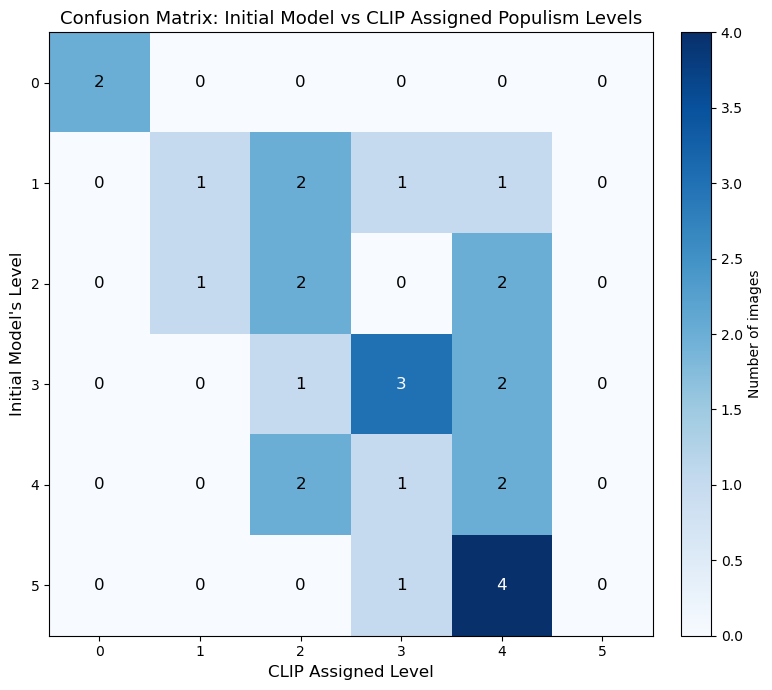

Matched 28/28 images
Exact matches:       10/28
Within 1 level:      21/28
Mean absolute error: 0.93


In [16]:
valid = [(i, ma) for i, ma in enumerate(model_assigned_levels) if ma is not None]
valid_idx   = [i for i, _ in valid]
valid_ma    = [ma for _, ma in valid]
valid_clip  = [image_levels[i] for i in valid_idx]
valid_names = [filenames[i] for i in valid_idx]

conf_matrix = np.zeros((6, 6), dtype=int)
for ma, clip_lvl in zip(valid_ma, valid_clip):
    conf_matrix[ma][clip_lvl] += 1

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(conf_matrix, cmap="Blues")
ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(range(6))
ax.set_yticklabels(range(6))
ax.set_xlabel("CLIP Assigned Level", fontsize=12)
ax.set_ylabel("Initial Model's Level", fontsize=12)
ax.set_title("Confusion Matrix: Initial Model vs CLIP Assigned Populism Levels", fontsize=13)

for i in range(6):
    for j in range(6):
        ax.text(j, i, conf_matrix[i][j], ha="center", va="center", fontsize=12,
                color="white" if conf_matrix[i][j] > conf_matrix.max() / 2 else "black")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Number of images")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

errors = [abs(valid_ma[i] - valid_clip[i]) for i in range(len(valid_idx))] 
print(f"Matched {len(valid_idx)}/{len(filenames)} images")
print(f"Exact matches:       {sum(e == 0 for e in errors)}/{len(errors)}")
print(f"Within 1 level:      {sum(e <= 1 for e in errors)}/{len(errors)}")
print(f"Mean absolute error: {np.mean(errors):.2f}")